# **---= Permite salvar os erros que ocorreram com a função Evaluate =---**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install ultralytics==8.4.24 #opencv-python pillow

In [ ]:
import os
import shutil
import random
from sklearn.model_selection import train_test_split
from PIL import Image
import yaml
import numpy as np
import cv2
import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader, random_split
import timm
from sklearn.metrics import accuracy_score, f1_score
from itertools import product
from tqdm import tqdm
from sklearn.model_selection import StratifiedShuffleSplit
from ultralytics import YOLO
import torch.nn as nn
import pandas as pd
import seaborn as sn
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import sympy
import time

In [ ]:
path = os.getcwd()
print(path)

#os.chdir(path)
#file_log = open(path + "/mensagem_final_classificar_V2.txt", "a")

/content


In [ ]:
# === Configurações Gerais ===
NUM_CLASSES = 18
INPUT_SIZE = 224  # conforme modelo Small treinado em 224×224
BATCH_SIZE = 32 # Padrão: 32
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATASET_LEAF = "/content/drive/MyDrive/TCC/Datasets/Imagens Folhas/Especies" # Dataset de folhas usado
DATASET_BARK = "/content/drive/MyDrive/TCC/Datasets/Imagens tronco/EspeciesCascas" # Dataset de cascas usado

FUSION_DATASET_TYPE = "Unitario"  # "Cartesiano" ou "Unitario"

In [ ]:
#  ===Dataset customizado ===
class ImageFolderDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        # Assumindo estrutura: root_dir/class_x/imagename.jpg
        self.samples = []
        classes = sorted(os.listdir(root_dir))
        self.class_to_idx = {cls_name:i for i,cls_name in enumerate(classes)}
        for cls_name in classes:
            cls_path = os.path.join(root_dir, cls_name)
            if not os.path.isdir(cls_path):
                continue
            for fname in os.listdir(cls_path):
                if fname.lower().endswith(('.png','.jpg','.jpeg','bmp')):
                    self.samples.append((os.path.join(cls_path, fname), self.class_to_idx[cls_name]))
        # embaralhar?
        np.random.seed(42)
        np.random.shuffle(self.samples)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        # leitura via OpenCV
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        # redimensionar
        img = cv2.resize(img, (INPUT_SIZE, INPUT_SIZE))
        # converter para float32 e normalizar [0,1]
        img = img.astype(np.float32) / 255.0
        # talvez normalização adicional conforme modelo (media/std)
        # usando valores padrão ImageNet
        mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
        std  = np.array([0.229, 0.224, 0.225], dtype=np.float32)
        img = (img - mean) / std
        # mudar de H×W×C para C×H×W
        img = np.transpose(img, (2,0,1))
        img_tensor = torch.from_numpy(img)
        label_tensor = torch.tensor(label, dtype=torch.long)
        return img_tensor, label_tensor

In [ ]:
class CartesianFusionDataset(Dataset):
    def __init__(self, ds_folha, ds_casca):
        self.samples = []

        # Extrair samples considerando Subset
        def get_samples(ds):
            if isinstance(ds, torch.utils.data.Subset):
                # Pegar apenas os índices do subset
                base_samples = ds.dataset.samples
                return [base_samples[i] for i in ds.indices]
            else:
                return ds.samples

        folha_samples = get_samples(ds_folha)
        casca_samples = get_samples(ds_casca)

        # Agrupar por classe
        folhas_por_classe = {}
        cascas_por_classe = {}

        for img, label in folha_samples:
            if label not in folhas_por_classe:
                folhas_por_classe[label] = []
            folhas_por_classe[label].append(img)

        for img, label in casca_samples:
            if label not in cascas_por_classe:
                cascas_por_classe[label] = []
            cascas_por_classe[label].append(img)

        if FUSION_DATASET_TYPE == "Cartesiano":
          # Produto cartesiano por classe
          for label in folhas_por_classe.keys():
              if label not in cascas_por_classe:
                  continue
              for f_img in folhas_por_classe[label]:
                  for c_img in cascas_por_classe[label]:
                      self.samples.append((f_img, c_img, label))
        elif FUSION_DATASET_TYPE == "Unitario":
          # Combinação pareada por classe (com reinício circular das cascas)
          for label in folhas_por_classe.keys():
              if label not in cascas_por_classe:
                  continue
              folhas = folhas_por_classe[label]
              cascas = cascas_por_classe[label]
              for i, f_img in enumerate(folhas):
                  c_img = cascas[i % len(cascas)]
                  self.samples.append((f_img, c_img, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        folha_path, casca_path, label = self.samples[idx]

        # Preprocessar imagens
        img_f = self.preprocess(folha_path)
        img_c = self.preprocess(casca_path)

        return img_f, img_c, torch.tensor(label, dtype=torch.long)

    def preprocess(self, img_path):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (INPUT_SIZE, INPUT_SIZE))
        img = img.astype(np.float32) / 255.0

        mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
        std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
        img = (img - mean) / std

        img = np.transpose(img, (2, 0, 1))
        return torch.from_numpy(img)

In [ ]:
def stratified_split(dataset, test_split=0.2, valid_split=0.1, seed=42):
    """
    Divide o dataset em treino, validação e teste mantendo a proporção das classes.

    Args:
        dataset: Dataset com atributo 'samples' [(path, label), ...]
        test_split: Proporção do teste em relação ao total (padrão: 0.1 = 10%)
        valid_split: Proporção da validação em relação ao (treino+validação) (padrão: 0.2 = 20%)
        seed: Seed para reprodutibilidade

    Returns:
        train_ds, valid_ds, test_ds: Subsets estratificados

    Nota: Com os valores padrão, a divisão real é:
        - Treino: 72% do total
        - Validação: 18% do total
        - Teste: 10% do total
    """
    # Extrair os rótulos
    labels = [label for _, label in dataset.samples]

    # Primeiro, separar Teste
    sss1 = StratifiedShuffleSplit(n_splits=1, test_size=test_split, random_state=seed)
    train_valid_idx, test_idx = next(sss1.split(np.zeros(len(labels)), labels))

    # Agora, separar Validação dentro do conjunto de treino+validação
    labels_train_valid = np.array(labels)[train_valid_idx]
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=valid_split, random_state=seed)
    train_idx, valid_idx = next(sss2.split(np.zeros(len(labels_train_valid)), labels_train_valid))

    # Reindexar para o dataset original
    train_idx = np.array(train_valid_idx)[train_idx]
    valid_idx = np.array(train_valid_idx)[valid_idx]

    # Criar Subsets
    train_ds = torch.utils.data.Subset(dataset, train_idx)
    valid_ds = torch.utils.data.Subset(dataset, valid_idx)
    test_ds  = torch.utils.data.Subset(dataset, test_idx)

    return train_ds, valid_ds, test_ds

In [ ]:
def generate_gradcam(model, img_tensor, target_class, model_name="model"):
    """
    Gera o mapa Grad-CAM para uma imagem e classe alvo.
    Retorna a imagem original sobreposta com o heatmap (numpy array H×W×3, uint8).
    """
    # Identificar a última camada convolucional conforme o modelo
    target_layer = None
    if "mobilenet" in model_name.lower():
        # MobileNetV4: última camada do último stage
        try:
            target_layer = model.blocks[-1][-1]  # último bloco
        except Exception:
            target_layer = list(model.children())[-2]
    elif "vit" in model_name.lower():
        # ViT não tem conv 2D clássica; usa a última norma do último bloco
        target_layer = model.blocks[-1].norm1
    elif "yolo" in model_name.lower():
        # YOLO: backbone é model[0], último layer do backbone
        #target_layer = model[0][-1]  # último layer do backbone nn.Sequential
        #target_layer = model[0][-2]  # C3k2 antes do SPPF
        target_layer = model[0][8]  # A2C2f, último bloco com parâmetros
    else:
        target_layer = list(model.modules())[-2]

    activations = {}
    gradients = {}

    def forward_hook(module, input, output):
        activations['value'] = output

    def backward_hook(module, grad_input, grad_output):
        gradients['value'] = grad_output[0]

    handle_f = target_layer.register_forward_hook(forward_hook)
    handle_b = target_layer.register_full_backward_hook(backward_hook)

    # Forward com grad habilitado
    model.eval()
    img_input = img_tensor.unsqueeze(0).to(DEVICE)
    with torch.enable_grad():
        img_input = img_input.requires_grad_(True)
        output = model(img_input)

        model.zero_grad()
        score = output[0, target_class]
        score.backward()

    handle_f.remove()
    handle_b.remove()

    act = activations['value'].detach().cpu()   # [1, C, H, W] ou [1, N, C] para ViT
    grad = gradients['value'].detach().cpu()

    # Para ViT os tensores são [1, N, C] (tokens); reshape necessário
    if act.dim() == 3:
        # [1, N, C] → pular token CLS, reshape para grade (suporta retângulo)
        act = act[:, 1:, :]   # remove CLS token
        grad = grad[:, 1:, :]
        n_tokens = act.shape[1]
        # Calcular grade a partir das dimensões reais da entrada
        img_h, img_w = img_tensor.shape[1], img_tensor.shape[2]
        patch_size = 16
        h = img_h // patch_size
        w = img_w // patch_size
        act = act.reshape(1, h, w, -1).permute(0, 3, 1, 2)   # [1, C, h, w]
        grad = grad.reshape(1, h, w, -1).permute(0, 3, 1, 2)

    weights = grad.mean(dim=(2, 3), keepdim=True)   # Global Average Pooling dos gradientes
    cam = (weights * act).sum(dim=1).squeeze()       # [H, W]
    cam = torch.relu(cam).numpy()

    if cam.max() > 0:
        cam = cam / cam.max()

    # Usar dimensões reais do tensor (suporta 224×224 e 448×224)
    orig_h, orig_w = img_tensor.shape[1], img_tensor.shape[2]

    cam_resized = cv2.resize(cam, (orig_w, orig_h))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    # Reconstruir imagem original desnormalizada
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    orig = img_tensor.numpy().transpose(1, 2, 0)   # [H, W, C]
    orig = (orig * std + mean).clip(0, 1)
    orig_uint8 = np.uint8(255 * orig)

    overlay = cv2.addWeighted(orig_uint8, 0.5, heatmap, 0.5, 0)
    return overlay

In [ ]:
# === Função para treinar por uma época ===
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    for imgs, labels in tqdm(loader, desc="Train"):
        imgs = imgs.to(DEVICE)
        labels = labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
    epoch_loss = running_loss / len(loader.dataset)
    return epoch_loss

# === Função para avaliar e salvar imagens classificadas incorretamente ===
def evaluate_and_save_errors(model, loader, class_names=None, save_errors=True,
                              output_dir="classification_errors", model_name="model", hybrid=True):
    """
    Avalia o modelo e opcionalmente salva as imagens classificadas incorretamente.

    Args:
        model: Modelo PyTorch a ser avaliado
        loader: DataLoader com o dataset de teste
        class_names: Lista com os nomes das classes
        save_errors: Se True, salva as imagens com erro de classificação
        output_dir: Diretório base onde salvar os erros
        model_name: Nome do modelo (usado para criar subpastas)

    Returns:
        acc: Acurácia
        f1: F1-Score
        error_info: Lista de dicionários com informações sobre os erros
    """
    model.eval()
    all_preds = []
    all_labels = []
    error_info = []
    inference_times = []

    # Criar diretório para salvar erros se necessário
    if save_errors:
        model_error_dir = os.path.join(output_dir, model_name)
        os.makedirs(model_error_dir, exist_ok=True)

        # Criar CSV para log dos erros
        csv_path = os.path.join(model_error_dir, "classification_errors.csv")
        csv_file = open(csv_path, 'w', encoding='utf-8')
        csv_file.write("imagem,classe_verdadeira,classe_predita,confianca,indice\n")

    # Warm-up da GPU para não contaminar a medição de tempo
    model.eval()
    with torch.no_grad():
        dummy = next(iter(loader))
        if hybrid:
            dummy_f, dummy_c, _ = dummy
            dummy_input = torch.cat([dummy_f.to(DEVICE), dummy_c.to(DEVICE)], dim=2)
        else:
            dummy_input, _ = dummy
            dummy_input = dummy_input.to(DEVICE)
        for _ in range(3):
            _ = model(dummy_input)
        if torch.cuda.is_available():
            torch.cuda.synchronize()

    # Diagnóstico: medir só o tempo de forward pass com tensor já na GPU
    with torch.no_grad():
        dummy_data = next(iter(loader))
        if hybrid:
            d_f, d_c, _ = dummy_data
            dummy_input = torch.cat([d_f.to(DEVICE), d_c.to(DEVICE)], dim=2)
        else:
            dummy_input, _ = dummy_data
            dummy_input = dummy_input.to(DEVICE)
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        t0 = time.time()
        for _ in range(100):
            model(dummy_input)
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        t1 = time.time()
        print(f"⚡ Forward pass puro (média 100x): {(t1-t0)/100/dummy_input.size(0)*1000:.2f} ms/imagem")

    #with torch.no_grad():
    sample_idx = 0
    error_candidates = []  # acumula erros para processar o Grad-CAM depois

    for batch_data in tqdm(loader, desc="Eval"):
        if hybrid:
            img_f, img_c, batch_labels = batch_data
            img_f, img_c = img_f.to(DEVICE), img_c.to(DEVICE)
            batch_imgs = torch.cat([img_f, img_c], dim=2)
        else:
            batch_imgs, batch_labels = batch_data
            batch_imgs = batch_imgs.to(DEVICE)
        batch_labels = batch_labels.to(DEVICE)

        with torch.no_grad():
            if torch.cuda.is_available():
                torch.cuda.synchronize()
            start_time = time.time()
            outputs = model(batch_imgs)
            if torch.cuda.is_available():
                torch.cuda.synchronize()
            end_time = time.time()
            inference_times.append((end_time - start_time) / batch_imgs.size(0))
            probs = torch.nn.functional.softmax(outputs, dim=1)
            confidences, preds = torch.max(probs, dim=1)

        for i in range(batch_imgs.size(0)):
            pred       = preds[i].item()
            label      = batch_labels[i].item()
            confidence = confidences[i].item()

            all_preds.append(pred)
            all_labels.append(label)

            if pred != label and save_errors:
                error_candidates.append({
                    'img_tensor_cpu': batch_imgs[i].cpu(),
                    'pred':           pred,
                    'label':          label,
                    'confidence':     confidence,
                    'sample_idx':     sample_idx,
                })

            sample_idx += 1

    # ── Grad-CAM e cópia de arquivos FORA da medição ──
    if save_errors:
        for err in error_candidates:
            pred       = err['pred']
            label      = err['label']
            confidence = err['confidence']
            s_idx      = err['sample_idx']

            dataset = loader.dataset
            if hasattr(dataset, 'dataset'):
                base_dataset = dataset.dataset
                actual_idx   = dataset.indices[s_idx]
            else:
                base_dataset = dataset
                actual_idx   = s_idx

            sample = base_dataset.samples[actual_idx]
            if hybrid:
                img_path       = sample[0]
                img_path_casca = sample[1]
            else:
                img_path = sample[0]
            img_name = os.path.basename(img_path)

            true_class = class_names[label] if class_names else f"class_{label}"
            pred_class = class_names[pred]  if class_names else f"class_{pred}"

            error_subdir = os.path.join(model_error_dir, f"{true_class}_as_{pred_class}")
            os.makedirs(error_subdir, exist_ok=True)

            dest_path = os.path.join(error_subdir, img_name)
            shutil.copy2(img_path, dest_path)
            if hybrid:
                casca_name = os.path.basename(img_path_casca)
                shutil.copy2(img_path_casca, os.path.join(error_subdir, casca_name))

            error_dict = {
                'image_path': img_path,
                'saved_path': dest_path,
                'true_label': label,
                'true_class': true_class,
                'pred_label': pred,
                'pred_class': pred_class,
                'confidence': confidence,
                'index':      actual_idx,
            }

            try:
                gradcam_img  = generate_gradcam(model, err['img_tensor_cpu'], pred, model_name=model_name)
                gradcam_name = os.path.splitext(img_name)[0] + "_gradcam.jpg"
                gradcam_path = os.path.join(error_subdir, gradcam_name)
                cv2.imwrite(gradcam_path, cv2.cvtColor(gradcam_img, cv2.COLOR_RGB2BGR))
                error_dict['gradcam_path'] = gradcam_path
            except Exception as e:
                print(f"⚠️  Grad-CAM falhou para {img_name}: {e}")
                error_dict['gradcam_path'] = None

            error_info.append(error_dict)
            csv_file.write(f"{img_name},{true_class},{pred_class},{confidence:.4f},{actual_idx}\n")

        csv_file.close()
        print(f"\n✅ Erros salvos em: {model_error_dir}")
        print(f"📊 Total de erros: {len(error_info)}/{sample_idx}")

    # Calcular métricas
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')

    # Matriz de confusão
    cm = confusion_matrix(all_labels, all_preds)
    df_cm = pd.DataFrame(cm, index=class_names, columns=class_names)

    plt.figure(figsize=(12, 10))
    sn.set(font_scale=1.2)
    sn.heatmap(df_cm, annot=True, fmt='d', cmap='Blues',
               annot_kws={"size": 12}, cbar_kws={'label': 'Contagem'})
    plt.ylabel('Classe Verdadeira')
    plt.xlabel('Classe Predita')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.title(f'Matriz de Confusão - {model_name}\nAcurácia: {acc:.4f} | F1-Score: {f1:.4f}', fontsize=14, fontweight='bold')
    plt.tight_layout()

    # Salvar matriz de confusão
    if save_errors:
        cm_path = os.path.join(model_error_dir, "confusion_matrix.png")
        plt.savefig(cm_path, dpi=150, bbox_inches='tight')
        print(f"📈 Matriz de confusão salva em: {cm_path}")
    plt.show()

    avg_time = np.mean(inference_times) * 1000  # em milissegundos
    print(f"⏱️  Tempo médio de inferência por imagem: {avg_time:.2f} ms")
    return acc, f1, avg_time, error_info

In [ ]:
def predict_and_show_gradcam_hybrid(model, img_path_folha, img_path_casca, class_names, model_name="model"):
    """
    Realiza a predição de um par folha+casca e exibe o Grad-CAM para o modelo híbrido.

    Args:
        model: Modelo PyTorch híbrido
        img_path_folha: Caminho para a imagem de folha
        img_path_casca: Caminho para a imagem de casca
        class_names: Lista com os nomes das classes
        model_name: Nome do modelo (usado para selecionar a camada correta no Grad-CAM)
    """
    def preprocess(img_path):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_orig = cv2.resize(img, (INPUT_SIZE, INPUT_SIZE))  # original para exibição
        img_float = img_orig.astype(np.float32) / 255.0
        mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
        std  = np.array([0.229, 0.224, 0.225], dtype=np.float32)
        img_norm = (img_float - mean) / std
        tensor = torch.from_numpy(np.transpose(img_norm, (2, 0, 1)))
        return tensor, img_orig

    tensor_f, orig_f = preprocess(img_path_folha)
    tensor_c, orig_c = preprocess(img_path_casca)

    # Concatenar na altura (448×224) — igual ao treinamento
    img_tensor = torch.cat([tensor_f, tensor_c], dim=1)

    # Inferência
    model.eval()
    with torch.no_grad():
        output = model(img_tensor.unsqueeze(0).to(DEVICE))
        probs = torch.nn.functional.softmax(output, dim=1)
        confidence, pred = torch.max(probs, dim=1)

    pred_class = class_names[pred.item()] if class_names else f"class_{pred.item()}"
    confidence_val = confidence.item()

    # Grad-CAM sobre a entrada concatenada
    gradcam_img = generate_gradcam(model, img_tensor, pred.item(), model_name=model_name)

    # O Grad-CAM tem altura 448; dividir ao meio para exibir sobre cada imagem
    mid = gradcam_img.shape[0] // 2
    gradcam_f = gradcam_img[:mid, :, :]
    gradcam_c = gradcam_img[mid:, :, :]

    # Exibir: 4 painéis — folha original, grad-cam folha, casca original, grad-cam casca
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))

    axes[0].imshow(orig_f)
    axes[0].set_title("Folha - Original")
    axes[0].axis("off")

    axes[1].imshow(gradcam_f)
    axes[1].set_title("Folha - Grad-CAM")
    axes[1].axis("off")

    axes[2].imshow(orig_c)
    axes[2].set_title("Casca - Original")
    axes[2].axis("off")

    axes[3].imshow(gradcam_c)
    axes[3].set_title("Casca - Grad-CAM")
    axes[3].axis("off")

    plt.suptitle(f"Modelo: {model_name} | Predição: {pred_class} ({confidence_val:.1%})", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

    print(f"Predição: {pred_class} | Confiança: {confidence_val:.4f}")
    return pred_class, confidence_val

In [ ]:
# ======= Função para montar o modelo MobileNetV4 adaptado para 15 classes ========
def create_mobilenet(num_classes=NUM_CLASSES, pretrained=True):
    model = timm.create_model('mobilenetv4_conv_small.e1200_r224_in1k', pretrained=pretrained)

    # Descongela tudo
    for param in model.parameters():
        param.requires_grad = True

    # Congela apenas o final
    for name, param in model.named_parameters():
        # Congela os primeiros blocos/stages da MobileNet
        # Congela 3 stages = 60% (mais conservador)
        if any(layer in name for layer in ['conv_stem', 'stages.0', 'stages.1', 'stages.2']):
            param.requires_grad = False

    model.reset_classifier(num_classes=num_classes)
    return model.to(DEVICE)

# ======= Função para montar o modelo Hybrid MobileNet (fusão folha+casca) ========
def create_hybrid_mobilenet(num_classes=NUM_CLASSES, pretrained=True):
    model = timm.create_model(
        'mobilenetv4_conv_small.e1200_r224_in1k',
        pretrained=pretrained
    )

    # Descongela tudo
    for param in model.parameters():
        param.requires_grad = True

    # Congela os primeiros stages
    for name, param in model.named_parameters():
        if any(layer in name for layer in ['conv_stem', 'stages.0', 'stages.1', 'stages.2']):
            param.requires_grad = False

    model.reset_classifier(num_classes=num_classes)
    return model.to(DEVICE)

# ======= Função para montar o modelo ViT-Tiny adaptado para 15 classes ========
def create_vit(num_classes=NUM_CLASSES, pretrained=True):
    # Carregar modelo base
    model = timm.create_model('vit_tiny_patch16_224', pretrained=pretrained)

    # Primeiro, descongela tudo
    for param in model.parameters():
        param.requires_grad = True

    # Agora CONGELA apenas os blocos iniciais (features básicas)
    for name, param in model.named_parameters():
        # Congela APENAS 2 blocos iniciais (17%), NÃO congela patch_embed
        if any(x in name for x in ["blocks.0", "blocks.1"]):
            param.requires_grad = False

    model.reset_classifier(num_classes=num_classes)
    return model.to(DEVICE)

# ======= Função para montar o modelo Hybrid ViT-Tiny (fusão folha+casca) ========
def create_hybrid_vit(num_classes=NUM_CLASSES, pretrained=True):
    model = timm.create_model(
        'vit_tiny_patch16_224',
        pretrained=pretrained,
        img_size=(448, 224)  # altura dobrada pela concatenação folha+casca
    )

    # Descongela tudo
    for param in model.parameters():
        param.requires_grad = True

    # Congela apenas os 2 blocos iniciais
    for name, param in model.named_parameters():
        if any(x in name for x in ["blocks.0", "blocks.1"]):
            param.requires_grad = False

    model.reset_classifier(num_classes=num_classes)
    return model.to(DEVICE)

# ======= Função para montar o modelo YOLOv12 adaptado para 15 classes ========
def create_yolo(num_classes=NUM_CLASSES, pretrained=True, freeze_stages=3):
    """
    Cria modelo de classificação usando backbone do YOLOv12.

    Args:
        num_classes: Número de classes para classificação
        pretrained: Se True, carrega pesos pré-treinados
        freeze_stages: Número de stages iniciais para congelar (0-4)
                      2 = recomendado (mantém features básicas: bordas, cores, texturas) OBS: Também é recomendado 3

    Estrutura YOLOv12:
        Stage 0: Stem - features muito básicas (bordas)
        Stage 1: C3k2 blocks - cores e texturas simples
        Stage 2: C3k2 blocks - texturas complexas
        Stage 3: C3k2 blocks - padrões intermediários
        Stage 4: C3k2 + SPPF - features de alto nível
    """

    # Carregar YOLOv12 pré-treinado
    if pretrained:
        yolo = YOLO('yolo12n.pt')  # ou yolo12s.pt, yolo12m.pt, yolo12l.pt, yolo12x.pt
    else:
        yolo = YOLO('yolo12n.yaml')  # modelo sem pesos

    # Acessar o modelo PyTorch interno
    full_model = yolo.model

    # Extrair apenas o backbone (sem neck e head de detecção)
    # YOLOv12 geralmente tem ~10 layers no backbone
    backbone_layers = []
    for i in range(10):  # Ajuste se necessário
        if i < len(full_model.model):
            backbone_layers.append(full_model.model[i])
        else:
            break

    backbone = nn.Sequential(*backbone_layers)

    # === CONGELAMENTO CORRETO ===
    # Primeiro, descongela tudo
    for param in backbone.parameters():
        param.requires_grad = True

    # Mapear layers para stages (aproximado para YOLOv12n)
    # Isso pode variar ligeiramente dependendo da versão (n/s/m/l/x)
    stage_to_layers = {
        0: [0, 1],      # Stem: Conv inicial
        1: [2, 3],      # Stage 1: Primeiros C3k2 blocks
        2: [4, 5],      # Stage 2: C3k2 intermediários
        3: [6, 7],      # Stage 3: C3k2 avançados
        4: [8, 9],      # Stage 4: C3k2 finais + SPPF
    }

    # Congela apenas os stages iniciais (features básicas)
    frozen_layers = []
    for stage_idx in range(freeze_stages):
        if stage_idx in stage_to_layers:
            for layer_idx in stage_to_layers[stage_idx]:
                if layer_idx < len(backbone):
                    for param in backbone[layer_idx].parameters():
                        param.requires_grad = False
                    frozen_layers.append(layer_idx)

    #print(f"❄️  Layers congeladas (features básicas): {frozen_layers}")

    # === AUTO-DETECTAR DIMENSÕES ===
    backbone.eval()
    with torch.no_grad():
        dummy_input = torch.randn(1, 3, 224, 224)
        if torch.cuda.is_available():
            dummy_input = dummy_input.cuda()
            backbone = backbone.cuda()

        features = backbone(dummy_input)

        # YOLOv12 pode retornar múltiplas escalas, pegar a última
        if isinstance(features, (list, tuple)):
            features = features[-1]

        # Shape: [batch, channels, height, width]
        in_features = features.shape[1]
        #print(f"✅ Features do backbone: {in_features} channels")
        #print(f"📐 Shape de saída: {features.shape}")

    backbone.train()

    # === CABEÇA DE CLASSIFICAÇÃO ===
    classifier_head = nn.Sequential(
        nn.AdaptiveAvgPool2d((1, 1)),           # Global Average Pooling
        nn.Flatten(),
        nn.BatchNorm1d(in_features),
        nn.Dropout(0.3),
        nn.Linear(in_features, 512),
        nn.ReLU(inplace=True),
        nn.BatchNorm1d(512),
        nn.Dropout(0.2),
        nn.Linear(512, num_classes)
    )

    # Modelo completo
    full_classifier = nn.Sequential(backbone, classifier_head)

    # Resumo
    total_params = sum(p.numel() for p in full_classifier.parameters())
    trainable_params = sum(p.numel() for p in full_classifier.parameters() if p.requires_grad)
    #print(f"\n📊 Parâmetros totais: {total_params:,}")
    #print(f"🔥 Parâmetros treináveis: {trainable_params:,} ({trainable_params/total_params*100:.1f}%)")
    #print(f"❄️  Parâmetros congelados: {total_params-trainable_params:,} ({(total_params-trainable_params)/total_params*100:.1f}%)")

    return full_classifier.to(DEVICE)

# ======= Função para montar o modelo Hybrid YOLOv12 (fusão folha+casca) ========
def create_hybrid_yolo(num_classes=NUM_CLASSES, pretrained=True, freeze_stages=3):
    if pretrained:
        yolo = YOLO('yolo12n.pt')
    else:
        yolo = YOLO('yolo12n.yaml')

    full_model = yolo.model
    backbone_layers = []
    for i in range(10):
        if i < len(full_model.model):
            backbone_layers.append(full_model.model[i])
        else:
            break

    backbone = nn.Sequential(*backbone_layers)

    for param in backbone.parameters():
        param.requires_grad = True

    stage_to_layers = {
        0: [0, 1],
        1: [2, 3],
        2: [4, 5],
        3: [6, 7],
        4: [8, 9],
    }
    frozen_layers = []
    for stage_idx in range(freeze_stages):
        if stage_idx in stage_to_layers:
            for layer_idx in stage_to_layers[stage_idx]:
                if layer_idx < len(backbone):
                    for param in backbone[layer_idx].parameters():
                        param.requires_grad = False
                    frozen_layers.append(layer_idx)

    # Auto-detectar dimensões com entrada 448×224 (concatenada na altura)
    backbone.eval()
    with torch.no_grad():
        dummy_input = torch.randn(1, 3, 448, 224).to(DEVICE)
        backbone = backbone.to(DEVICE)
        features = backbone(dummy_input)
        if isinstance(features, (list, tuple)):
            features = features[-1]
        in_features = features.shape[1]

    backbone.train()

    classifier_head = nn.Sequential(
        nn.AdaptiveAvgPool2d((1, 1)),
        nn.Flatten(),
        nn.BatchNorm1d(in_features),
        nn.Dropout(0.3),
        nn.Linear(in_features, 512),
        nn.ReLU(inplace=True),
        nn.BatchNorm1d(512),
        nn.Dropout(0.2),
        nn.Linear(512, num_classes)
    )

    return nn.Sequential(backbone, classifier_head).to(DEVICE)

In [ ]:
# === Função principal para rodar Grid Search sobre epochs e learning rate ===
def run_test(dataset_roo, valid_split=0.1, test_split=0.2):
    # whichModel só pode ser "bark" ou "leaf"
    '''if whichModel not in ["bark", "leaf"]:
        raise ValueError("whichModel deve ser 'bark' ou 'leaf'")
    if whichModel == "leaf":
      whichFolder = "Folha"
      #folha_teste = "/content/drive/MyDrive/TCC/Datasets/Imagens Folhas/Especies/Coite/Coite R1.jpg"
      #folha_teste = "/content/drive/MyDrive/TCC/Datasets/Testes/Jambolao G25.jpg"
      #folha_teste = "/content/drive/MyDrive/TCC/Datasets/Testes/Carvalho_Teste4.jpg"
      #test_img_path = "/content/drive/MyDrive/TCC/Datasets/Testes/Carvalho_Teste4.jpg"
      #test_img_path = "/content/drive/MyDrive/TCC/Datasets/Imagens Folhas/Especies/Araca/Araca B7.jpg"
      test_img_path = "/content/drive/MyDrive/TCC/Datasets/Imagens Folhas/Especies/Carvalho/Carvalho B20.jpg"
    elif whichModel == "bark":
      whichFolder = "Casca"
      #casca_teste = "/content/drive/MyDrive/TCC/Datasets/Imagens tronco/EspeciesCascas/Coite/Coite B3.jpg"
      #casca_teste = "/content/drive/MyDrive/TCC/Datasets/Testes/Caterete D14.jpg"
      #casca_teste = "/content/drive/MyDrive/TCC/Datasets/Testes/Carvalho_Teste3.jpg"
      test_img_path = "/content/drive/MyDrive/TCC/Datasets/Testes/Carvalho_Teste3.jpg"'''

    test_img_path_casca = "/content/drive/MyDrive/TCC/Datasets/Testes/Carvalho_Teste3.jpg"
    test_img_path_folha = "/content/drive/MyDrive/TCC/Datasets/Imagens Folhas/Especies/Carvalho/Carvalho B20.jpg"

    # carregar dataset completo
    ds_f = ImageFolderDataset(DATASET_LEAF)
    ds_c = ImageFolderDataset(DATASET_BARK)
    _, _, test_f = stratified_split(ds_f, test_split=test_split, valid_split=valid_split, seed=42)
    _, _, test_c = stratified_split(ds_c, test_split=test_split, valid_split=valid_split, seed=42)
    test_fusion = CartesianFusionDataset(test_f, test_c)
    test_loader_hybrid = DataLoader(test_fusion, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

    print(f"\nDataset: {len(ds_f)} imagens")
    print(f"\nDataset: {len(ds_c)} imagens")
    print(f"\nDataset: {len(test_fusion)} imagens")

     # ✅ Extrair nomes ORIGINAIS das classes na ordem correta
    class_names = [name for name, idx in sorted(ds_c.class_to_idx.items(), key=lambda x: x[1])]
    print(f"Classes detectadas ({len(ds_c.class_to_idx.keys())}): {class_names}")

    criterion = nn.CrossEntropyLoss()

    modelMN = create_hybrid_mobilenet(num_classes=NUM_CLASSES, pretrained=False)
    modelMN.load_state_dict(torch.load(f"/content/drive/MyDrive/TCC/Datasets/main_weights/{FUSION_DATASET_TYPE}/hybrid_input_mobilenet_best.pt", map_location=DEVICE))
    modelMN.to(DEVICE)
    acc_test, f1_test, avg_time, errors = evaluate_and_save_errors(
        modelMN,
        test_loader_hybrid,
        class_names,
        save_errors=True,
        output_dir="/content/drive/MyDrive/TCC/classification_errors_input",
        model_name=f"HybridMobileNetV4"
    )
    print(f"MobileNetV4 - acc: {acc_test:.6f}, f1: {f1_test:.6f}, time={avg_time:.2f}ms")

    predict_and_show_gradcam_hybrid(
        model=modelMN,
        img_path_folha=test_img_path_folha,
        img_path_casca=test_img_path_casca,
        class_names=class_names,
        model_name="HybridMobileNetV4"
    )

    modelHV = create_hybrid_vit(num_classes=NUM_CLASSES, pretrained=False)
    modelHV.load_state_dict(torch.load(f"/content/drive/MyDrive/TCC/Datasets/main_weights/{FUSION_DATASET_TYPE}/hybrid_input_vit_best.pt", map_location=DEVICE))
    modelHV.to(DEVICE)
    acc_test, f1_test, avg_time, errors = evaluate_and_save_errors(
        modelHV,
        test_loader_hybrid,
        class_names,
        save_errors=True,
        output_dir="/content/drive/MyDrive/TCC/classification_errors_input",
        model_name=f"Hybrid_ViT_Tiny"
    )
    print(f"ViT Tiny - acc: {acc_test:.6f}, f1: {f1_test:.6f}, time={avg_time:.2f}ms")

    predict_and_show_gradcam_hybrid(
        model=modelHV,
        img_path_folha=test_img_path_folha,
        img_path_casca=test_img_path_casca,
        class_names=class_names,
        model_name="HybridViT"
    )

    modelHY = create_hybrid_yolo(num_classes=NUM_CLASSES, pretrained=True)
    modelHY.load_state_dict(torch.load(f"/content/drive/MyDrive/TCC/Datasets/main_weights/{FUSION_DATASET_TYPE}/hybrid_input_YOLO_best.pt", map_location=DEVICE))
    modelHY.to(DEVICE)
    for i, layer in enumerate(modelHY[0]):
      print(i, layer.__class__.__name__)
    acc_test, f1_test, avg_time, errors = evaluate_and_save_errors(
        modelHY,
        test_loader_hybrid,
        class_names,
        save_errors=True,
        output_dir="/content/drive/MyDrive/TCC/classification_errors_input",
        model_name=f"Hybrid_YOLOv12"
    )
    print(f"YOLOv12 - acc: {acc_test:.6f}, f1: {f1_test:.6f}, time={avg_time:.2f}ms")

    predict_and_show_gradcam_hybrid(
        model=modelHY,
        img_path_folha=test_img_path_folha,
        img_path_casca=test_img_path_casca,
        class_names=class_names,
        model_name="HybridYOLOv12"
    )


--------------- Testes dos melhores modelos ---------------


--------------- Testes ---------------
Início...

Dataset: 835 imagens

Dataset: 586 imagens

Dataset: 167 imagens
Classes detectadas (18): ['Abacateiro', 'Araca', 'Brinco de Indio', 'Cajueiro', 'Canela Amarela', 'Carvalho', 'Caterete', 'Cerejeira', 'Coite', 'Embauba', 'Fruta do conde', 'Grevilha', 'Jambolao', 'Laranja Champanhe', 'Louro Pardo', 'Oiti', 'Pau Brasil', 'Peroba Rosa']


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


⚡ Forward pass puro (média 100x): 45.68 ms/imagem


Eval: 100%|██████████| 6/6 [00:52<00:00,  8.74s/it]



✅ Erros salvos em: /content/drive/MyDrive/TCC/classification_errors_input/HybridMobileNetV4
📊 Total de erros: 7/167
📈 Matriz de confusão salva em: /content/drive/MyDrive/TCC/classification_errors_input/HybridMobileNetV4/confusion_matrix.png


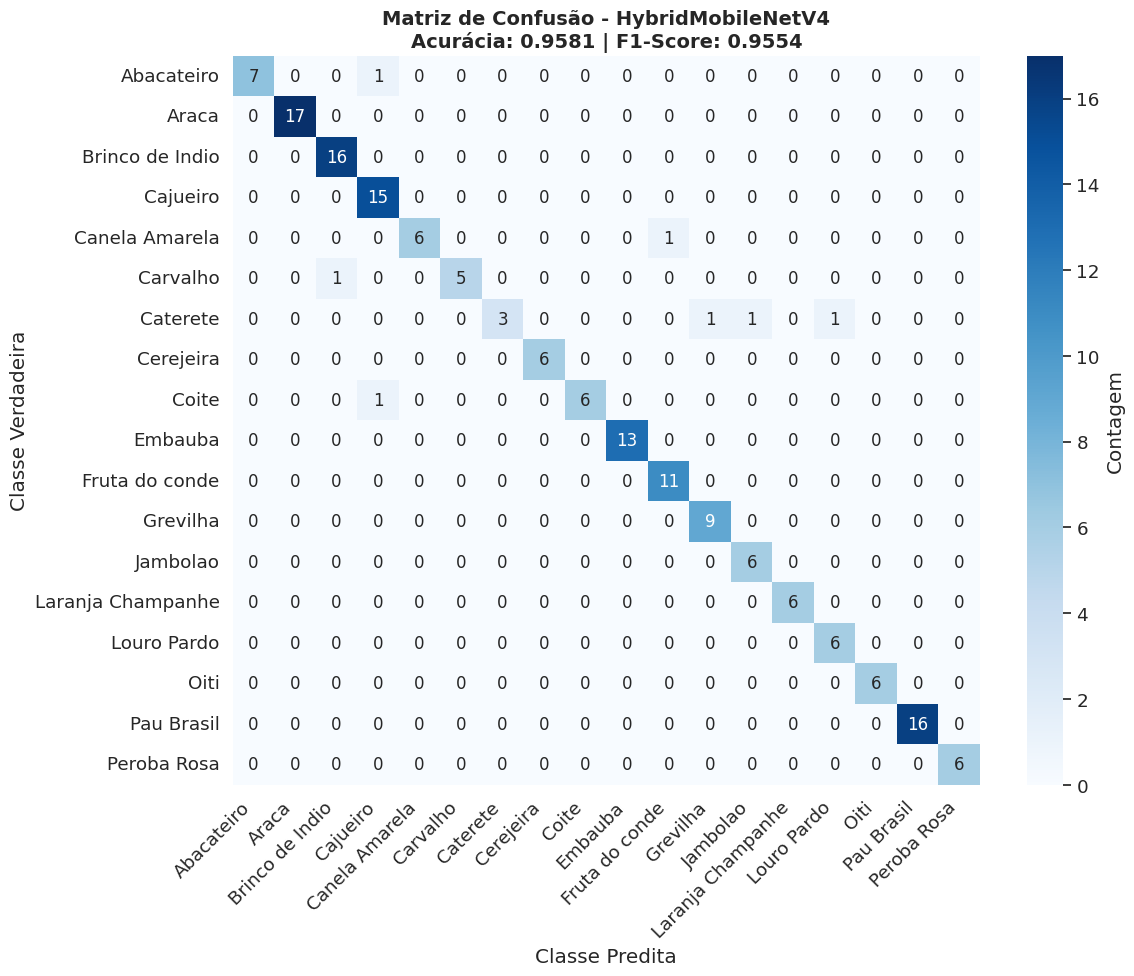

⏱️  Tempo médio de inferência por imagem: 71.38 ms
MobileNetV4 - acc: 0.958084, f1: 0.955371, time=71.38ms


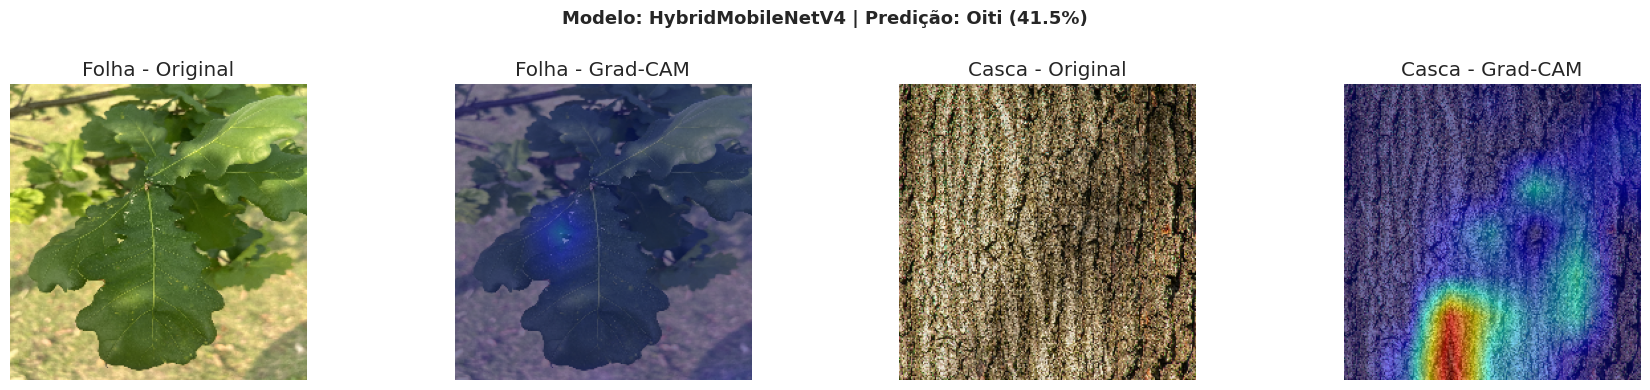

Predição: Oiti | Confiança: 0.4154


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


⚡ Forward pass puro (média 100x): 143.09 ms/imagem


Eval: 100%|██████████| 6/6 [01:07<00:00, 11.18s/it]



✅ Erros salvos em: /content/drive/MyDrive/TCC/classification_errors_input/Hybrid_ViT_Tiny
📊 Total de erros: 11/167
📈 Matriz de confusão salva em: /content/drive/MyDrive/TCC/classification_errors_input/Hybrid_ViT_Tiny/confusion_matrix.png


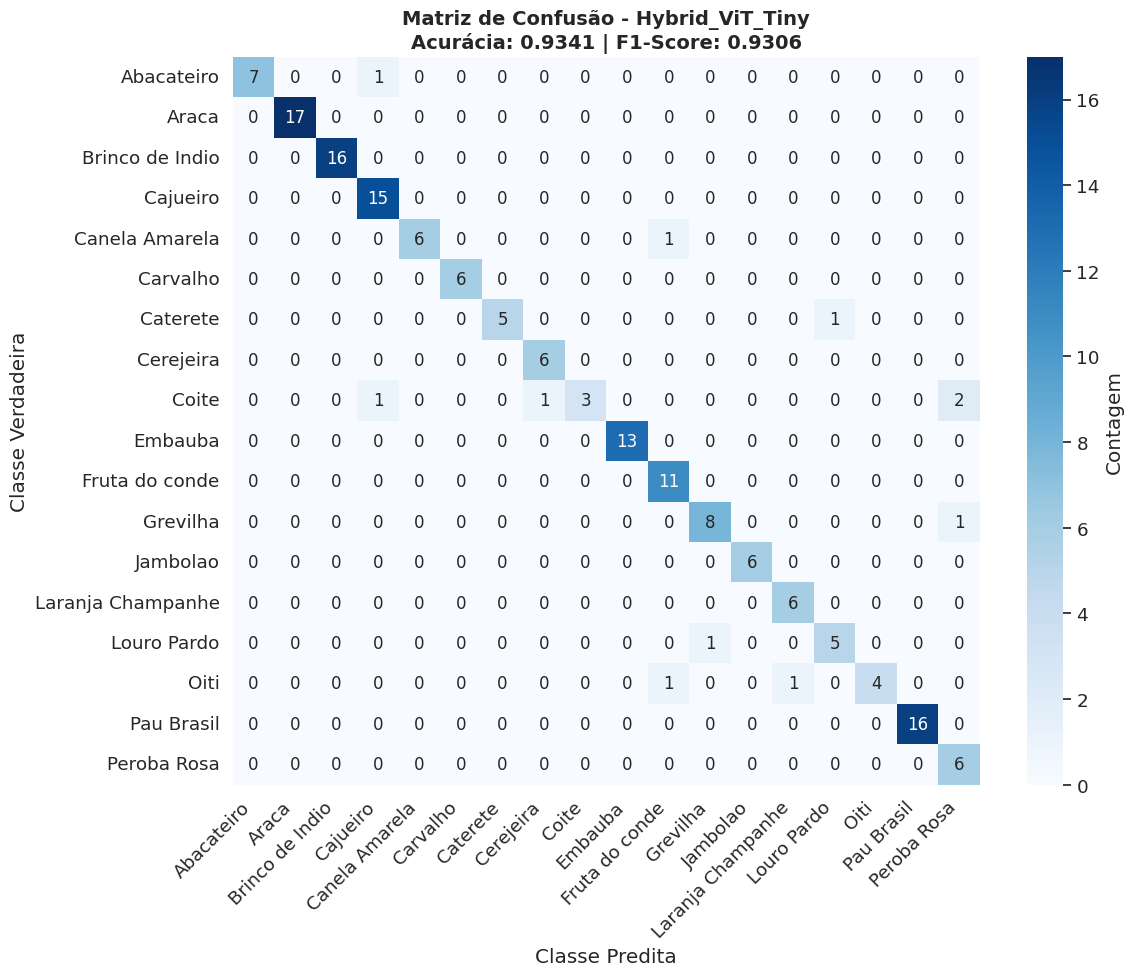

⏱️  Tempo médio de inferência por imagem: 181.15 ms
ViT Tiny - acc: 0.934132, f1: 0.930572, time=181.15ms


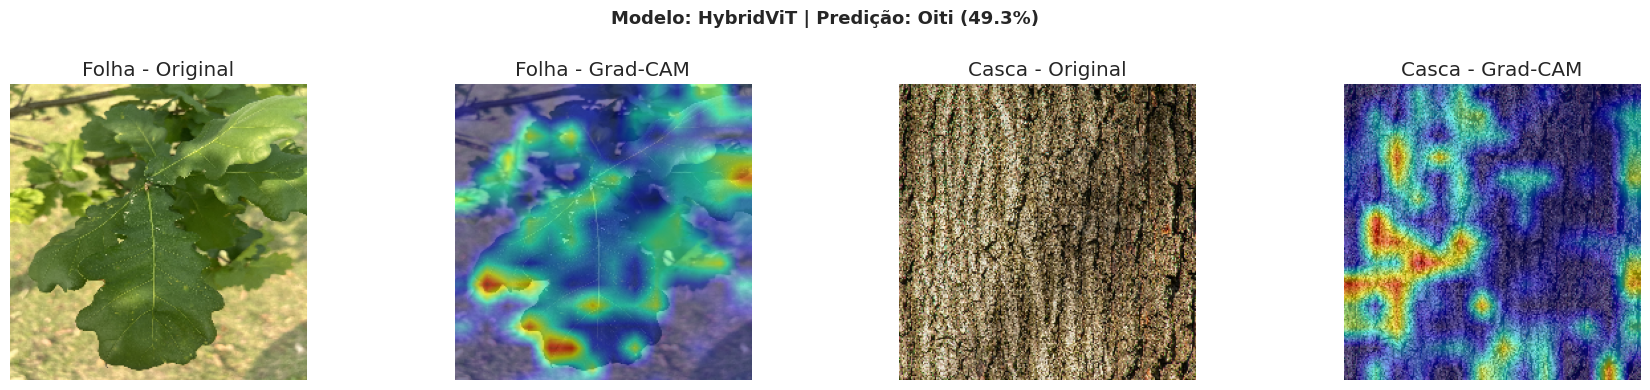

Predição: Oiti | Confiança: 0.4932
0 Conv
1 Conv
2 C3k2
3 Conv
4 C3k2
5 Conv
6 A2C2f
7 Conv
8 A2C2f
9 Upsample


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


⚡ Forward pass puro (média 100x): 47.00 ms/imagem


Eval: 100%|██████████| 6/6 [00:54<00:00,  9.05s/it]



✅ Erros salvos em: /content/drive/MyDrive/TCC/classification_errors_input/Hybrid_YOLOv12
📊 Total de erros: 8/167
📈 Matriz de confusão salva em: /content/drive/MyDrive/TCC/classification_errors_input/Hybrid_YOLOv12/confusion_matrix.png


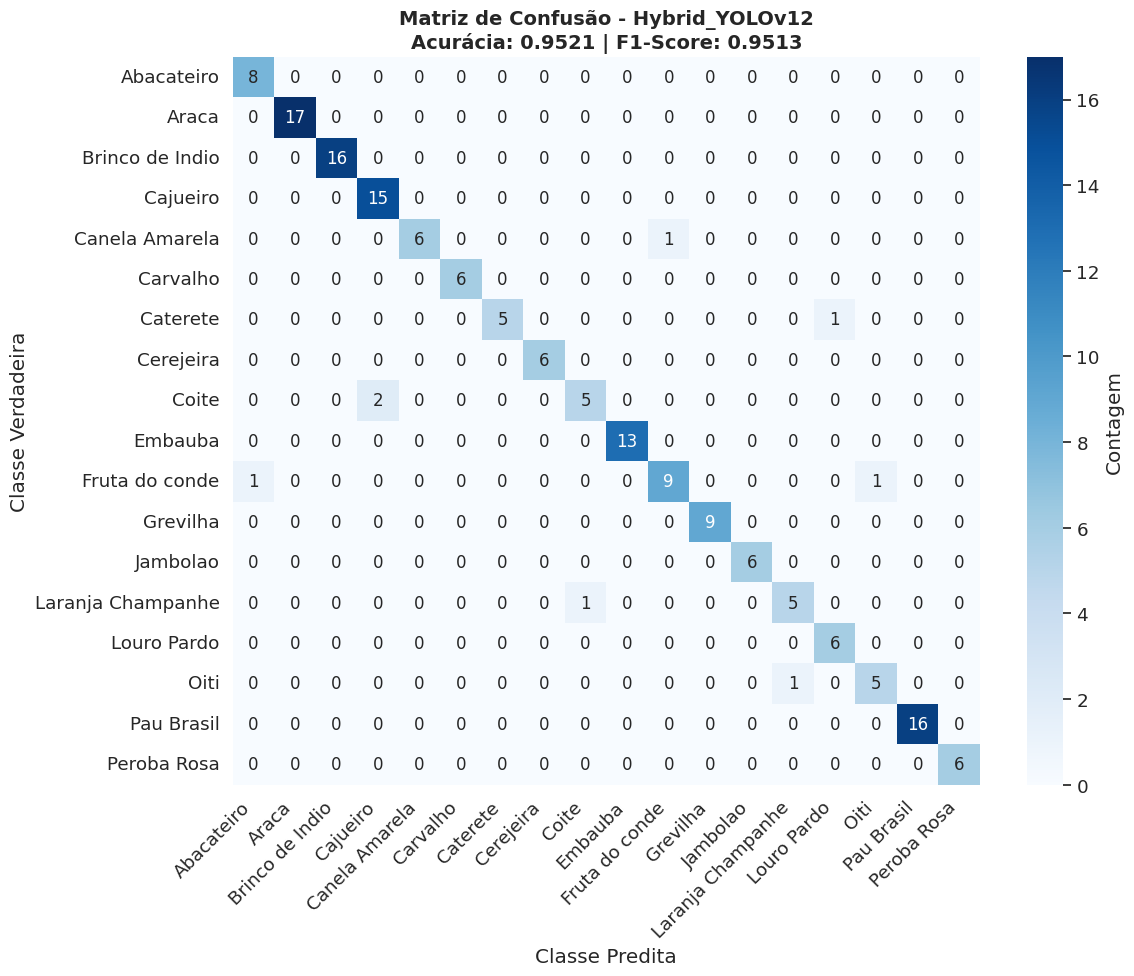

⏱️  Tempo médio de inferência por imagem: 95.40 ms
YOLOv12 - acc: 0.952096, f1: 0.951255, time=95.40ms


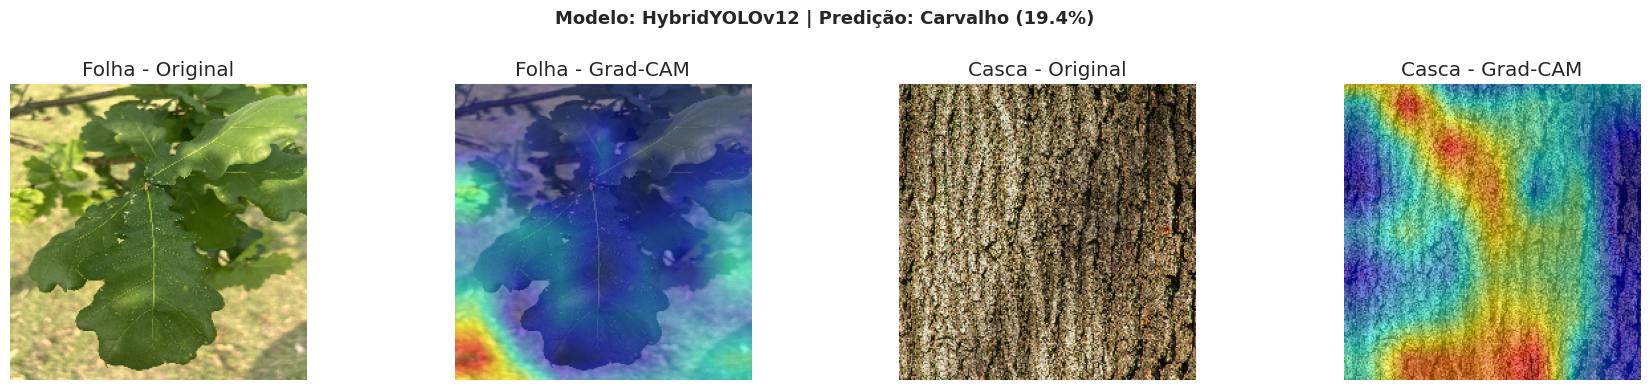

Predição: Carvalho | Confiança: 0.1938
...Fim



In [ ]:
# === Função Main ===
if __name__ == "__main__":
    try:
        print("\n--------------- Testes dos melhores modelos ---------------\n")
        # Defina aqui o caminho para o diretório de imagens
        dataset_leaf = DATASET_LEAF
        dataset_bark = DATASET_BARK
        # Defina lista de valores para hyperparâmetros
        # Rodar grid
        print("\n--------------- Testes ---------------\nInício...")
        run_test(dataset_leaf, valid_split=0.1, test_split=0.2)
        print("...Fim\n")
    except KeyboardInterrupt:
        print("Programa encerrado via terminal...")